------

-----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

# Análisis de Rentabilidad de Planes de Telecomunicaciones - Megaline

## Introducción

Como analista de datos para el operador de telecomunicaciones Megaline, he sido encargado de realizar un análisis comparativo de rentabilidad entre los dos planes de prepago que ofrece la empresa: Surf y Ultimate. 

### Contexto del negocio

El departamento comercial de Megaline necesita determinar cuál de estos planes genera mayores ingresos para optimizar la asignación del presupuesto publicitario. Esta decisión estratégica impactará directamente en las campañas de marketing y la adquisición de nuevos clientes.

### Objetivos del análisis

Este proyecto tiene como propósitos principales:

- **Analizar el comportamiento de uso** de los clientes en ambos planes (llamadas, SMS y datos)
- **Calcular y comparar los ingresos mensuales** generados por cada plan
- **Identificar patrones de consumo** que distingan a los usuarios de cada tarifa
- **Realizar pruebas estadísticas** para validar las diferencias observadas
- **Proporcionar recomendaciones estratégicas** basadas en evidencia para el departamento comercial

### Metodología

El análisis se basará en datos de 500 clientes de Megaline durante el año 2018, incluyendo:
- Información demográfica y de suscripción
- Registros detallados de llamadas, mensajes y uso de internet
- Cálculo de ingresos considerando las tarifas base y cargos por excesos

A través de técnicas de análisis exploratorio de datos, estadística descriptiva y pruebas de hipótesis, buscaremos responder la pregunta central: ¿Qué plan de prepago es más rentable para Megaline?

## Inicialización

In [52]:
# Cargar todas las librerías
import matplotlib.pyplot as plt
import math as mt
import numpy as np
import pandas as pd
from scipy import stats as st

## Cargar datos

In [53]:
# Carga los archivos de datos en diferentes DataFrames
df_users=pd.read_csv('/datasets/megaline_users.csv')
df_calls=pd.read_csv('/datasets/megaline_calls.csv')
df_messages=pd.read_csv('/datasets/megaline_messages.csv')
df_plans=pd.read_csv('/datasets/megaline_plans.csv')
df_internet=pd.read_csv('/datasets/megaline_internet.csv')


## Preparar los datos

In [54]:
print(df_users.head())
df_users.info()

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    

In [55]:
print(df_calls.head())
df_calls.info()

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [56]:
print(df_messages.head())
df_messages.info()

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [57]:
print(df_internet.head())
df_internet.info()

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [58]:
print(df_plans.head())
df_plans.info()

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pla

In [59]:
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])
print("Users:", df_users[['reg_date', 'churn_date']].dtypes)
print("Calls:", df_calls[['call_date']].dtypes)
print("Messages:", df_messages[['message_date']].dtypes)
print("Internet:", df_internet[['session_date']].dtypes)


Users: reg_date      datetime64[ns]
churn_date    datetime64[ns]
dtype: object
Calls: call_date    datetime64[ns]
dtype: object
Messages: message_date    datetime64[ns]
dtype: object
Internet: session_date    datetime64[ns]
dtype: object


Las correcciones a las tablas corresponden al tipo de dato de las fechas, ya que las mismas se encuentran en tipo object cuando con una buena practica estas deberían de ser tipo datetime.

El cambio se realizo en las tablas de users, calls, internet y messages en sus respectivas columnas que representan fechas.


## Tarifas

In [60]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(df_plans.isna().sum())
print(df_plans.head(10))
print('=============================================================================')
print(df_plans.describe())


messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
       messages_included  mb_per_month_included  minutes_included  \
count           2.000000               2.000000          2.000000   
mean          525.000000           23040.000000       1750.000000   
std           671.751442           10861.160159       1767.766953   
min            50.000000           15360.000000        500.000000   
25

In [61]:
# Imprime una muestra de los datos para las tarifas
print(df_plans.sample())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  


La tabla df_plans contiene dos tarifas, Surf y Ultimate, con valores coherentes para los límites incluidos y los costos adicionales según la descripción del proyecto. No se observan valores ausentes ni problemas en los tipos de datos, y la muestra aleatoria confirma que la información está correctamente estructurada. El consumo de datos se expresa en megabytes, lo cual deberá considerarse en etapas posteriores del análisis. En esta sección no se identifican inconsistencias que requieran correcciones.

## Corregir datos

Después de examinar detalladamente el DataFrame df_plans mediante:
- Análisis de información general con .info()
- Revisión de estadísticas descriptivas con .describe()
- Inspección de muestras de datos

**No se encontraron errores que requieran corrección:**
- Sin valores nulos (2/2 registros completos en todas las columnas)
- Tipos de datos apropiados para cada variable
- Valores numéricos coherentes y lógicos
- Consistencia con la descripción del proyecto

**Conclusión**: df_plans no requiere limpieza de datos.

## Enriquecer los datos

Se agregó una nueva columna que representa el límite mensual de datos incluidos en gigabytes, con el fin de facilitar los cálculos posteriores del consumo excedente, ya que las tarifas adicionales se cobran por gigabyte.

In [62]:
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024

## Usuarios/as

In [63]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(df_users.isna().sum())
print(df_users.head(10))
print('=============================================================================')
print(df_users.describe())

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64
   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little 

In [64]:
# Imprime una muestra de datos para usuarios
print(df_users.sample(10))


     user_id first_name  last_name  age  \
357     1357        Ria      Beach   61   
454     1454   Kymberly      Cohen   56   
46      1046      Beata     Hooper   67   
320     1320       Bert      Wells   23   
267     1267        Gia     Parker   53   
128     1128     Lucius  Fernandez   41   
126     1126   Jermaine    Mcguire   68   
482     1482     Armand      Glenn   70   
198     1198       Russ      Horne   69   
352     1352      Gavin   Galloway   48   

                                          city   reg_date      plan churn_date  
357                        Baton Rouge, LA MSA 2018-05-30      surf        NaT  
454          San Antonio-New Braunfels, TX MSA 2018-05-30  ultimate        NaT  
46          Boston-Cambridge-Newton, MA-NH MSA 2018-02-19      surf        NaT  
320     Los Angeles-Long Beach-Anaheim, CA MSA 2018-02-23      surf        NaT  
267                       St. Louis, MO-IL MSA 2018-03-12      surf        NaT  
128                          Knoxville, 

La tabla df_users contiene información de 500 usuarios, incluyendo datos demográficos, ciudad de residencia, fecha de registro, plan contratado y fecha de cancelación del servicio. En la muestra de datos se observa que la mayoría de los usuarios no presenta una fecha en la columna churn_date, lo cual indica que continúan utilizando el servicio, de acuerdo con el diccionario de datos del proyecto. Estos valores ausentes no representan un error.

Las columnas numéricas, como age, presentan valores dentro de rangos razonables, y las variables categóricas y de fecha se encuentran correctamente estructuradas. El único aspecto identificado es la presencia de valores ausentes en la columna churn_date, los cuales indican que el usuario sigue utilizando el servicio, por lo que no requieren corrección en esta etapa.

### Corregir los datos

Después del análisis detallado de df_users:

- Los tipos de datos fueron corregidos previamente (fechas en formato datetime)
- Los valores ausentes en churn_date representan información valiosa (usuarios activos)
- No se identificaron errores estructurales o inconsistencias

**Conclusión**: No se requieren correcciones en df_users. Los datos están listos para el análisis.

### Enriquecer los datos

Teniendo en cuenta la necesidad de comprender y diferenciar los usuarios activos de los no activos, se agrego una nueva columna llamada is_active en la tabla de df_users, para complementar la información que nos da la columna churn_date respecto a la actividad de los usuarios. 

Se tomo la decisión de no eliminar dichos datos ausentes, ya que representan información valiosa para el análisis y se utiliza en otra columna que contiene en datos boléanos donde True es usuario activo y False es usuario que abandono el servicio.

In [65]:
df_users['is_active'] = df_users['churn_date'].isna()

## Llamadas

In [66]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(df_calls.isna().sum())
print(df_calls.head(10))
print('=============================================================================')
print(df_calls.describe())

id           0
user_id      0
call_date    0
duration     0
dtype: int64
         id  user_id  call_date  duration
0   1000_93     1000 2018-12-27      8.52
1  1000_145     1000 2018-12-27     13.66
2  1000_247     1000 2018-12-27     14.48
3  1000_309     1000 2018-12-28      5.76
4  1000_380     1000 2018-12-30      4.22
5  1000_388     1000 2018-12-31      2.20
6  1000_510     1000 2018-12-27      5.75
7  1000_521     1000 2018-12-28     14.18
8  1000_530     1000 2018-12-28      5.77
9  1000_544     1000 2018-12-26      4.40
             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000


In [67]:
# Imprime una muestra de datos para las llamadas
print(df_calls.sample(10))

               id  user_id  call_date  duration
129367   1465_757     1465 2018-09-21      1.68
34783     1132_52     1132 2018-05-02      6.20
28706    1109_333     1109 2018-11-12     21.45
350      1002_372     1002 2018-11-15     12.16
101813   1362_572     1362 2018-09-20     23.98
13849     1059_67     1059 2018-09-24      0.89
104715   1368_430     1368 2018-09-09      5.86
21004    1077_971     1077 2018-12-16      8.81
115495   1404_289     1404 2018-11-27      1.43
95059   1336_1019     1336 2018-10-18     17.14


La tabla df_calls contiene información sobre las llamadas realizadas por los usuarios, incluyendo el identificador del usuario, la fecha y la duración de cada llamada expresada en minutos. En la información general se observa la presencia de llamadas con duración igual a 0.00 minutos, las cuales pueden corresponder a llamadas perdidas o no conectadas.

Asimismo, la columna de fecha fue previamente convertida al tipo datetime, lo que permite realizar análisis temporales de forma adecuada. Los valores con duración cero no representan un error de formato, pero requieren consideración en etapas posteriores del análisis, donde se evaluará si deben incluirse o excluirse del cálculo del consumo mensual de minutos, de acuerdo con las reglas de facturación del proyecto.

### Corregir los datos

En la tabla de llamadas se identificaron registros con duración igual a 0.00 minutos, los cuales pueden corresponder a llamadas no conectadas o perdidas. Estos valores no representan un error de formato, pero no aportan al consumo real de minutos, por lo que se excluyen del cálculo del uso mensual mediante un filtrado de los registros con duración mayor a cero.

In [68]:
df_calls = df_calls[df_calls['duration'] > 0].copy()

df_calls['duration'] = np.ceil(df_calls['duration'])

df_calls['month'] = df_calls['call_date'].dt.month

### Enriquecer los datos

Para facilitar el análisis del consumo mensual de llamadas, se agregó una variable que indica el mes en el que se realizó cada llamada, lo que permitirá agrupar el uso por usuario y por periodo.

In [69]:
df_calls['month'] = df_calls['call_date'].dt.month

## Mensajes

In [70]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(df_messages.isna().sum())
print(df_messages.head(10))
print('=============================================================================')
print(df_messages.describe())

id              0
user_id         0
message_date    0
dtype: int64
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28
            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000


In [71]:
# Imprime una muestra de datos para los mensajes
print(df_messages.sample(10))

              id  user_id message_date
21980  1132_1533     1132   2018-10-11
72522   1470_150     1470   2018-11-30
51508    1335_97     1335   2018-10-23
12862   1084_102     1084   2018-10-29
10748    1077_19     1077   2018-10-20
9797     1075_52     1075   2018-10-30
71566   1466_218     1466   2018-07-11
16867    1112_32     1112   2018-12-22
10084   1076_210     1076   2018-08-05
50479   1329_461     1329   2018-09-18


La tabla df_messages contiene registros de los mensajes enviados por los usuarios, incluyendo el identificador del usuario y la fecha de envío. En la información general se observa que no existen valores ausentes y que la variable user_id presenta valores dentro del rango esperado. La muestra de datos confirma que cada registro corresponde a un mensaje individual correctamente asociado a un usuario y a una fecha específica.

La columna message_date fue previamente convertida al tipo datetime, lo que permite realizar análisis temporales adecuados. No se identifican problemas en los tipos de datos ni inconsistencias que requieran correcciones adicionales en esta etapa, por lo que el conjunto de datos se encuentra listo para su uso en el análisis posterior.

### Corregir los datos

Tras la revisión inicial de la tabla df_messages, no se identificaron valores ausentes ni inconsistencias en los tipos de datos. Cada registro corresponde a un mensaje individual correctamente asociado a un usuario y a una fecha de envío. Por lo tanto, no fue necesario realizar correcciones en esta etapa.

In [72]:
print("=== VERIFICACIONES DE CALIDAD DE DATOS ===")

# 1. Verificar valores faltantes
print("1. Valores faltantes por columna:")
print(df_messages.isnull().sum())

# 2. Verificar duplicados
print(f"\n2. Registros duplicados: {df_messages.duplicated().sum()}")

# 3. Verificar consistencia de tipos de datos
print(f"\n3. Tipos de datos:")
print(df_messages.dtypes)

# 4. Verificar rango de fechas (coherencia temporal)
print(f"\n4. Rango de fechas:")
print(f"   Fecha mínima: {df_messages['message_date'].min()}")
print(f"   Fecha máxima: {df_messages['message_date'].max()}")

# 5. Verificar consistencia de user_id con tabla principal
valid_users = set(df_users['user_id'])
message_users = set(df_messages['user_id'])
orphan_users = message_users - valid_users
print(f"\n5. Usuarios en mensajes sin registro en tabla principal: {len(orphan_users)}")

print("\n=== RESULTADO: No se requieren correcciones ===")

=== VERIFICACIONES DE CALIDAD DE DATOS ===
1. Valores faltantes por columna:
id              0
user_id         0
message_date    0
dtype: int64

2. Registros duplicados: 0

3. Tipos de datos:
id                      object
user_id                  int64
message_date    datetime64[ns]
dtype: object

4. Rango de fechas:
   Fecha mínima: 2018-01-15 00:00:00
   Fecha máxima: 2018-12-31 00:00:00

5. Usuarios en mensajes sin registro en tabla principal: 0

=== RESULTADO: No se requieren correcciones ===


### Enriquecer los datos

Se agregó la variable month a partir de la fecha de envío del mensaje, con el fin de facilitar el análisis y la agregación mensual del número de mensajes por usuario.

In [73]:
df_messages['month'] = df_messages['message_date'].dt.month

## Internet

In [74]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(df_internet.isna().sum())
print(df_internet.head(10))
print('=============================================================================')
print(df_internet.describe())

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92
             user_id        mb_used
count  104825.000000  104825.000000
mean     1242.496361     366.713701
std       142.053913     277.170542
min      1000.000000       0.000000
25%      1122.000000     136.080000
50%      1236.000000     343.980000
75%      1367.000000     554.610000
max      1499.000000    1693.470000


In [75]:
# Imprime una muestra de datos para el tráfico de internet
print(df_internet.sample(10))

             id  user_id session_date  mb_used
99054  1467_191     1467   2018-12-16   179.02
70640  1329_408     1329   2018-10-21   912.43
97474  1459_103     1459   2018-11-27   905.77
75277  1354_161     1354   2018-10-06   760.57
69690   1325_92     1325   2018-11-22     0.00
22082  1100_286     1100   2018-12-15   554.69
29337   1134_34     1134   2018-12-14   162.35
64636   1297_23     1297   2018-12-03   599.18
86679   1403_27     1403   2018-12-02   202.25
37422   1169_52     1169   2018-12-24   407.07




La tabla df_internet contiene registros de las sesiones de uso de internet por parte de los usuarios, incluyendo el identificador del usuario, la fecha de la sesión y el volumen de datos consumidos en megabytes. En la información general se observa que no existen valores ausentes en ninguna de las columnas, y que los tipos de datos son adecuados para el análisis.

En la muestra de datos se identifican sesiones con un consumo de 0.00 MB, lo cual puede corresponder a sesiones sin transferencia efectiva de datos. Estos valores no representan un error de registro, pero deberán ser considerados en etapas posteriores del análisis, ya que el cálculo del consumo de datos se realiza a nivel mensual y con redondeo a gigabytes, de acuerdo con las reglas de facturación del proyecto.



### Corregir los datos

Tras la revisión inicial de la tabla df_internet, no se identificaron valores ausentes ni problemas en los tipos de datos. Aunque se observan sesiones con consumo igual a 0.00 MB, estos registros no representan un error, ya que el cálculo del uso de datos se realiza de forma mensual. Por esta razón, no fue necesario realizar correcciones en esta etapa.

### Enriquecer los datos

Se agregó la variable month a partir de la fecha de la sesión para facilitar la agregación del consumo de datos por usuario y por mes en las siguientes etapas del análisis.

In [76]:
df_internet['month'] = df_internet['session_date'].dt.month

## Estudiar las condiciones de las tarifas

In [77]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_plans[['plan_name',
          'usd_monthly_pay',
          'minutes_included',
          'messages_included',
          'gb_per_month_included',
          'usd_per_minute',
          'usd_per_message',
          'usd_per_gb']]


,plan_name,usd_monthly_pay,minutes_included,messages_included,gb_per_month_included,usd_per_minute,usd_per_message,usd_per_gb
0,surf,20,500,50,15.0,0.03,0.03,10
1,ultimate,70,3000,1000,30.0,0.01,0.01,7


## Agregar datos por usuario



In [78]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.calls_per_month = (
calls_per_month = df_calls.groupby(['user_id', 'month']).agg({'id': 'count'}).reset_index()
calls_per_month.head()

,user_id,month,id
0,1000,12,16
1,1001,8,22
2,1001,9,38
3,1001,10,47
4,1001,11,49


In [79]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_month = df_calls.groupby(["user_id","month"]).agg({"duration":"sum"}).reset_index()
minutes_per_month.head()

,user_id,month,duration
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [80]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_month = (df_messages.groupby(['user_id', 'month']).agg({'id': 'count'}).reset_index())
messages_per_month.head()

,user_id,month,id
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [81]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
volume_per_month = df_internet.groupby(["user_id", "month"]).agg({"mb_used": "sum"}).reset_index()
volume_per_month["gb_used"] = np.ceil(volume_per_month["mb_used"] / 1024)
volume_per_month.head()

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


In [82]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
user_monthly_data = calls_per_month.merge(
    minutes_per_month, 
    on=['user_id', 'month'], 
    how='outer'
)
user_monthly_data = user_monthly_data.merge(
    messages_per_month,
    on=['user_id', 'month'], 
    how='outer'
)
user_monthly_data = user_monthly_data.merge(
    volume_per_month,
    on=['user_id', 'month'], 
    how='outer'
)
user_monthly_data = user_monthly_data.rename(columns={
    'id_x': 'calls_count', 
    'id_y': 'messages_count'
})
user_monthly_data.head(10)

,user_id,month,calls_count,duration,messages_count,mb_used,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,22.0,182.0,30.0,6919.15,7.0
2,1001,9,38.0,315.0,44.0,13314.82,14.0
3,1001,10,47.0,393.0,53.0,22330.49,22.0
4,1001,11,49.0,426.0,36.0,18504.30,19.0
5,1001,12,46.0,412.0,44.0,19369.18,19.0
6,1002,10,8.0,59.0,15.0,6552.01,7.0
7,1002,11,48.0,386.0,32.0,19345.08,19.0
8,1002,12,38.0,384.0,41.0,14396.24,15.0
9,1003,12,118.0,1104.0,50.0,27044.14,27.0


In [83]:
user_monthly_data = user_monthly_data.merge(
    df_users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)

user_monthly_data = user_monthly_data.merge(
    df_plans, 
    left_on='plan', 
    right_on='plan_name', 
    how='left'
)

user_monthly_data = user_monthly_data.drop('plan_name', axis=1)

user_monthly_data.head()

,user_id,month,calls_count,duration,messages_count,mb_used,gb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,30.0
1,1001,8,22.0,182.0,30.0,6919.15,7.0,surf,50,15360,500,20,10,0.03,0.03,15.0
2,1001,9,38.0,315.0,44.0,13314.82,14.0,surf,50,15360,500,20,10,0.03,0.03,15.0
3,1001,10,47.0,393.0,53.0,22330.49,22.0,surf,50,15360,500,20,10,0.03,0.03,15.0
4,1001,11,49.0,426.0,36.0,18504.30,19.0,surf,50,15360,500,20,10,0.03,0.03,15.0


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [84]:
# Calcula el ingreso mensual para cada usuario
user_monthly_data['excess_minutes'] = (user_monthly_data['duration'] - user_monthly_data['minutes_included']).clip(lower=0)

user_monthly_data['excess_messages'] = (user_monthly_data['messages_count'] - user_monthly_data['messages_included']).clip(lower=0)

user_monthly_data['excess_gb'] = np.maximum(0, np.ceil(user_monthly_data['mb_used'] / 1024) - user_monthly_data['gb_per_month_included'])

user_monthly_data['additional_minutes_cost'] = (
    user_monthly_data['excess_minutes'] * user_monthly_data['usd_per_minute']
)

user_monthly_data['additional_messages_cost'] = (
    user_monthly_data['excess_messages'] * user_monthly_data['usd_per_message']
)

user_monthly_data['additional_data_cost'] = (
    user_monthly_data['excess_gb'] * user_monthly_data['usd_per_gb']
)
user_monthly_data['monthly_revenue'] = (
    user_monthly_data['usd_monthly_pay'] +
    user_monthly_data['additional_minutes_cost'] +
    user_monthly_data['additional_messages_cost'] +
    user_monthly_data['additional_data_cost']
)
user_monthly_data.head()

,user_id,month,calls_count,duration,messages_count,mb_used,gb_used,plan,messages_included,mb_per_month_included,...,usd_per_message,usd_per_minute,gb_per_month_included,excess_minutes,excess_messages,excess_gb,additional_minutes_cost,additional_messages_cost,additional_data_cost,monthly_revenue
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,1000,30720,...,0.01,0.01,30.0,0.0,0.0,0.0,0.0,0.00,0.0,70.00
1,1001,8,22.0,182.0,30.0,6919.15,7.0,surf,50,15360,...,0.03,0.03,15.0,0.0,0.0,0.0,0.0,0.00,0.0,20.00
2,1001,9,38.0,315.0,44.0,13314.82,14.0,surf,50,15360,...,0.03,0.03,15.0,0.0,0.0,0.0,0.0,0.00,0.0,20.00
3,1001,10,47.0,393.0,53.0,22330.49,22.0,surf,50,15360,...,0.03,0.03,15.0,0.0,3.0,7.0,0.0,0.09,70.0,90.09
4,1001,11,49.0,426.0,36.0,18504.30,19.0,surf,50,15360,...,0.03,0.03,15.0,0.0,0.0,4.0,0.0,0.00,40.0,60.00


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

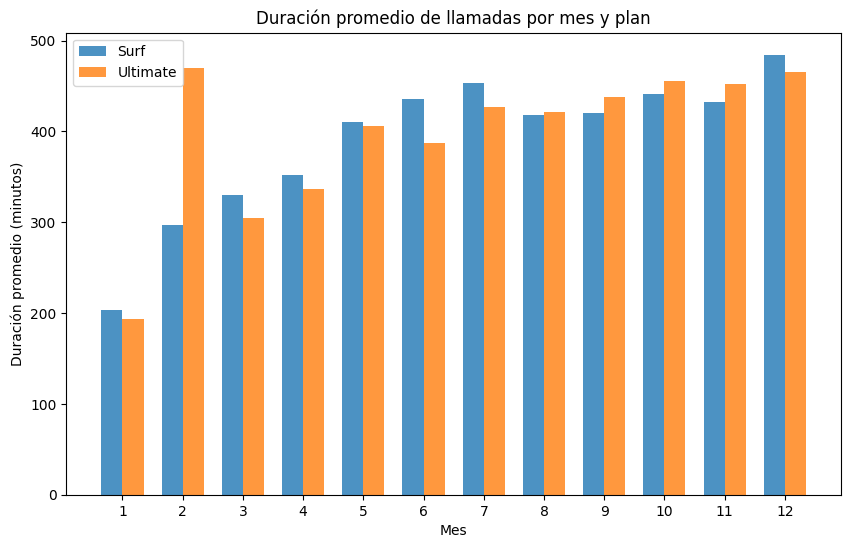

In [85]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
monthly_avg = user_monthly_data.groupby(['month', 'plan'])['duration'].mean().reset_index()
surf_data = monthly_avg[monthly_avg['plan'] == 'surf']
ultimate_data = monthly_avg[monthly_avg['plan'] == 'ultimate']

x = range(len(surf_data['month']))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], surf_data['duration'], width, label='Surf', alpha=0.8)
plt.bar([i + width/2 for i in x], ultimate_data['duration'], width, label='Ultimate', alpha=0.8)

plt.xlabel('Mes')
plt.ylabel('Duración promedio (minutos)')
plt.title('Duración promedio de llamadas por mes y plan')
plt.xticks(x, surf_data['month'])
plt.legend()
plt.show()

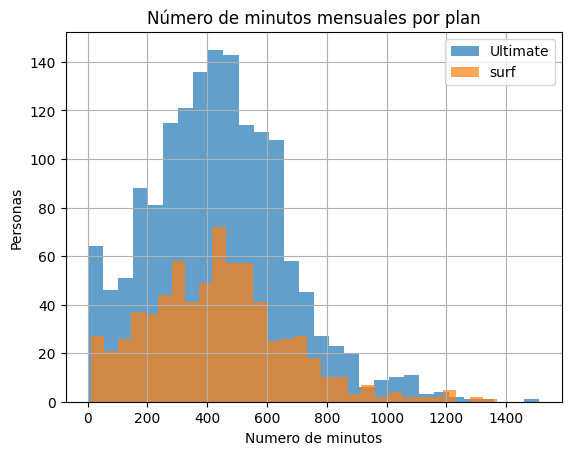

In [86]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
plan_df = user_monthly_data.groupby('plan')['duration']
plan_df.hist(alpha=0.7, bins=30)
plt.title("Número de minutos mensuales por plan")
plt.xlabel("Numero de minutos")
plt.ylabel("Personas")
plt.legend(["Ultimate","surf"])

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [87]:


# Calcula la media y la varianza de la duración mensual de llamadas.
monthly_calls_mean=user_monthly_data["duration"].mean()
monthly_calls_var=user_monthly_data["duration"].var()
print("Mean=",monthly_calls_mean,"Var=",monthly_calls_var)



Mean= 436.32402482269504 Var= 53690.19340924816


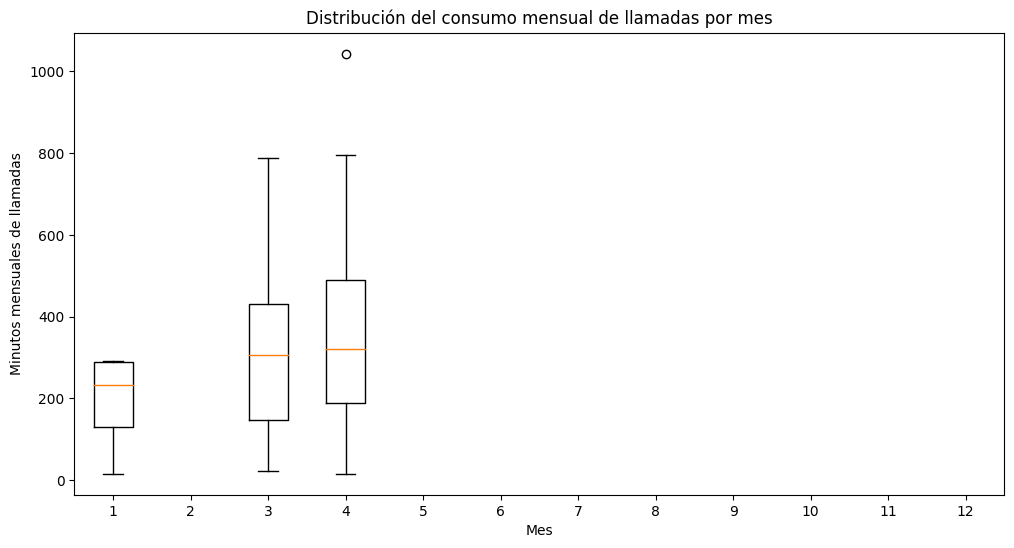

In [88]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(12, 6))
months = sorted(user_monthly_data['month'].unique())  # Solo meses con datos
data = [user_monthly_data.loc[user_monthly_data['month'] == m, 'duration'] 
        for m in months]

plt.boxplot(data, labels=months, showfliers=True)
plt.xlabel('Mes')
plt.ylabel('Minutos mensuales de llamadas')
plt.title('Distribución del consumo mensual de llamadas por mes')
plt.show()

Distribución de datos: Las llamadas presentan una distribución asimétrica hacia la derecha, lo que indica que la mayoría de usuarios tienen un consumo bajo-moderado de minutos, mientras que pocos usuarios realizan llamadas de larga duración.

Comparación entre planes: En general, el uso de minutos entre los planes Surf y Ultimate se mantiene equilibrado a lo largo de los meses. Sin embargo, se observa una anomalía significativa en febrero.

Anomalía en febrero: Los usuarios del plan Ultimate registraron más de 400 minutos promedio en febrero, muy superior al resto de meses. 
Esto puede indicar:
- Posibles promociones especiales del plan Ultimate en febrero
- Mayor adopción del plan Ultimate durante este mes
- Eventos puntuales que incentivaron mayor uso de llamadas

Implicaciones: Esta anomalía sugiere que las estrategias promocionales pueden influir significativamente en el comportamiento de uso de los usuarios.

### Mensajes

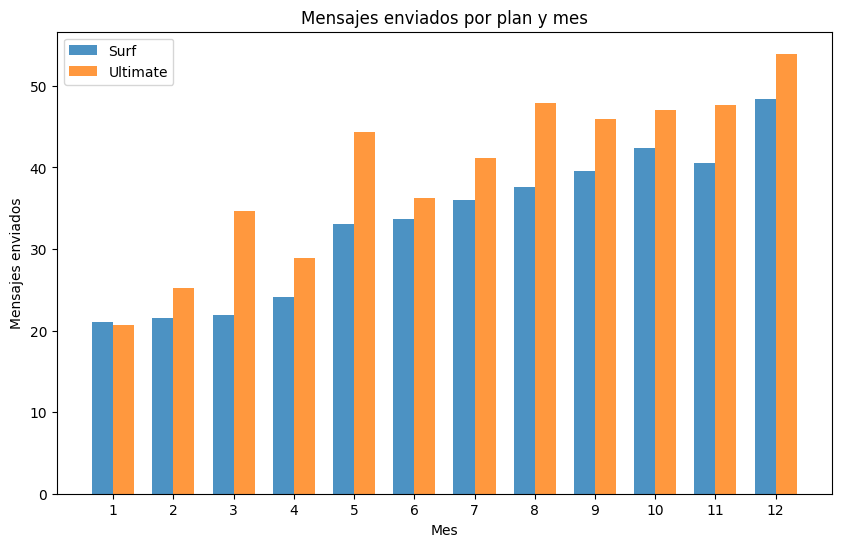

In [89]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
monthly_avg = user_monthly_data.groupby(['month', 'plan'])['messages_count'].mean().reset_index()
surf_data = monthly_avg[monthly_avg['plan'] == 'surf']
ultimate_data = monthly_avg[monthly_avg['plan'] == 'ultimate']

x = range(len(surf_data['month']))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], surf_data['messages_count'], width, label='Surf', alpha=0.8)
plt.bar([i + width/2 for i in x], ultimate_data['messages_count'], width, label='Ultimate', alpha=0.8)

plt.xlabel('Mes')
plt.ylabel('Mensajes enviados')
plt.title('Mensajes enviados por plan y mes')
plt.xticks(x, surf_data['month'])
plt.legend()
plt.show()


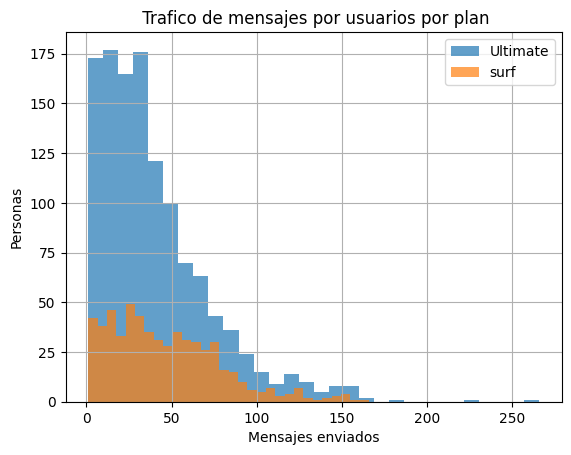

In [90]:
# Compara la cantidad de mensajes enviados por usuarios por plan
messages_plan_df = user_monthly_data.groupby('plan')['messages_count']
messages_plan_df.hist(alpha=0.7, bins=30)
plt.title(" Trafico de mensajes por usuarios por plan")
plt.xlabel("Mensajes enviados")
plt.ylabel("Personas")
plt.legend(["Ultimate","surf"])

In [91]:
# Calcula la media y la varianza de mensajes por plan.
monthly_internet_ultimate=user_monthly_data[user_monthly_data["plan"]=="ultimate"]
monthly_internet_surf=user_monthly_data[user_monthly_data["plan"]=="surf"]
mean_ultimate_m=monthly_internet_ultimate["messages_count"].mean()
var_ultimate_m=monthly_internet_ultimate["messages_count"].var()
mean_surf_m=monthly_internet_surf["messages_count"].mean()
var_surf_m=monthly_internet_surf["messages_count"].var()
print("Mean=",mean_ultimate_m,"Var=",var_ultimate_m,"Std=",mt.sqrt(var_ultimate_m))
print("Mean=",mean_surf_m,"Var=",var_surf_m,"Std=",mt.sqrt(var_surf_m))

Mean= 46.29623287671233 Var= 1085.183107568317 Std= 32.942117533156804
Mean= 40.10965630114566 Var= 1091.3442310038054 Std= 33.03549955735202


Conclusiones sobre el uso de mensajes:

Distribución: Ambos planes presentan distribución asimétrica positiva, con alta concentración en el primer cuartil.

Comparación entre planes: Los usuarios de Ultimate envían consistentemente más mensajes (46.3 vs 40.1 promedio) en todos los meses.

Variabilidad: Las varianzas similares indican patrones de comportamiento similares, solo difiere el volumen promedio.

Interpretación: Los usuarios del plan Ultimate realizan un uso más intensivo de los mensajes, lo que concuerda con el precio del plan y sugiere que está dirigido a empresarios y personas en cargos laborales de alto nivel.

### Internet

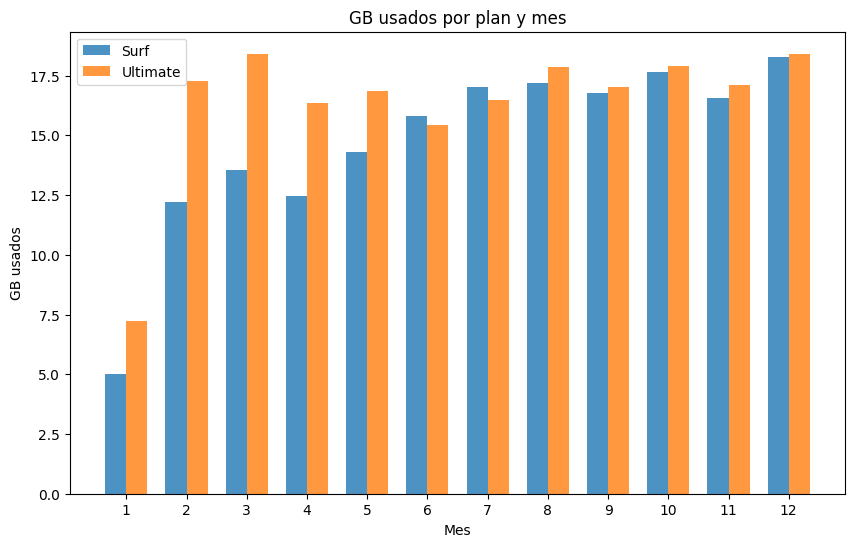

In [92]:
# comparar el trafico de internet por usuario por mes

monthly_avg = user_monthly_data.groupby(['month', 'plan'])['gb_used'].mean().reset_index()
surf_data = monthly_avg[monthly_avg['plan'] == 'surf']
ultimate_data = monthly_avg[monthly_avg['plan'] == 'ultimate']

x = range(len(surf_data['month']))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], surf_data['gb_used'], width, label='Surf', alpha=0.8)
plt.bar([i + width/2 for i in x], ultimate_data['gb_used'], width, label='Ultimate', alpha=0.8)

plt.xlabel('Mes')
plt.ylabel('GB usados')
plt.title('GB usados por plan y mes')
plt.xticks(x, surf_data['month'])
plt.legend()
plt.show()


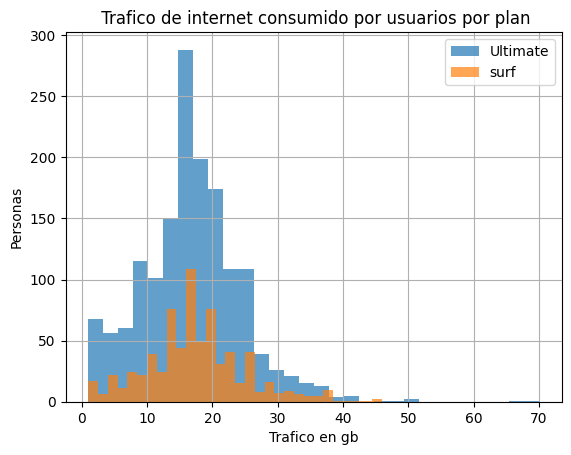

In [93]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
internet_plan_df = user_monthly_data.groupby('plan')['gb_used']
internet_plan_df.hist(alpha=0.7, bins=30)
plt.title(" Trafico de internet consumido por usuarios por plan")
plt.xlabel("Trafico en gb")
plt.ylabel("Personas")
plt.legend(["Ultimate","surf"])

In [94]:
# Calcula la media y la varianza del trafico de internet por plan.

monthly_internet_ultimate=user_monthly_data[user_monthly_data["plan"]=="ultimate"]
monthly_internet_surf=user_monthly_data[user_monthly_data["plan"]=="surf"]
mean_ultimate=monthly_internet_ultimate["gb_used"].mean()
var_ultimate=monthly_internet_ultimate["gb_used"].var()
mean_surf=monthly_internet_surf["gb_used"].mean()
var_surf=monthly_internet_surf["gb_used"].var()
print("Mean=",mean_ultimate,"Var=",var_ultimate,"Std=",mt.sqrt(var_ultimate))
print("Mean=",mean_surf,"Var=",var_surf,"Std=",mt.sqrt(var_surf))


Mean= 17.331015299026426 Var= 58.494733090294865 Std= 7.648184953980576
Mean= 16.831193838254173 Var= 59.473734090854755 Std= 7.711921556321404


Distribución similar: Ambos planes presentan distribución asimétrica positiva con estadísticas descriptivas prácticamente iguales.

Diferencia en volumen: Ultimate registra un consumo total significativamente mayor de gigas.

Patrones de uso:
- Surf: Usuarios casuales que frecuentemente exceden límites y pagan GB extra

- Ultimate: Uso regularizado que sugiere un perfil más formal/empresarial

Implicación: Los usuarios de Ultimate planifican mejor su consumo, mientras que los de Surf tienen un uso más impredecible.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

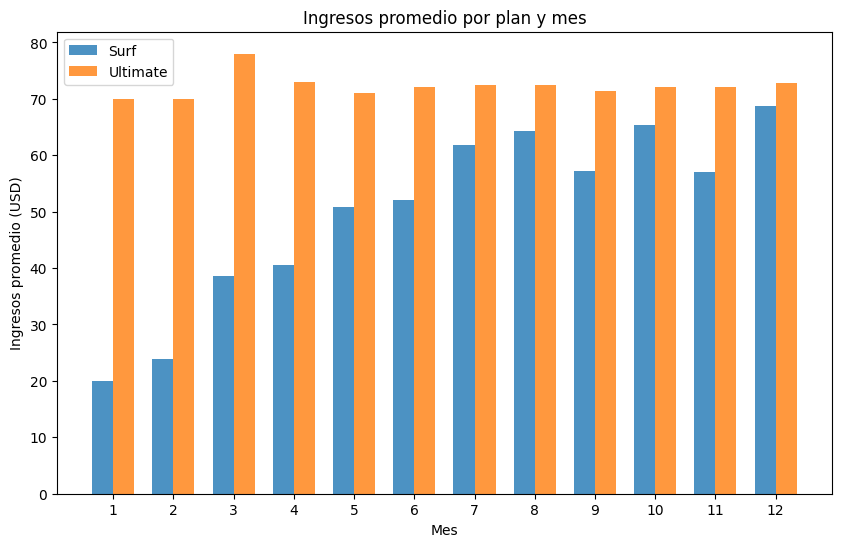

In [95]:
#comprara la cantidad de ingresos por mes por plan
monthly_avg_revenue = user_monthly_data.groupby(['month', 'plan'])['monthly_revenue'].mean().reset_index()
surf_data_revenue = monthly_avg_revenue[monthly_avg_revenue['plan'] == 'surf']
ultimate_data_revenue = monthly_avg_revenue[monthly_avg_revenue['plan'] == 'ultimate']

x_revenue = range(len(surf_data_revenue['month']))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x_revenue], surf_data_revenue['monthly_revenue'], width, label='Surf', alpha=0.8)
plt.bar([i + width/2 for i in x_revenue], ultimate_data_revenue['monthly_revenue'], width, label='Ultimate', alpha=0.8)
plt.xlabel('Mes')
plt.ylabel('Ingresos promedio (USD)')
plt.title('Ingresos promedio por plan y mes')
plt.xticks(x_revenue, surf_data_revenue['month'])
plt.legend()
plt.show()

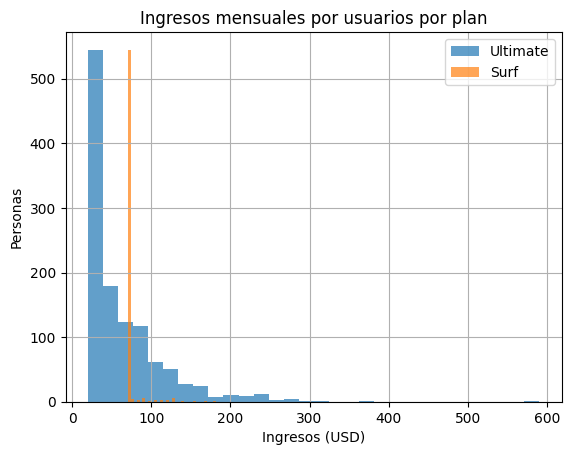

In [96]:
# Compara la cantidad ingresos por plan
revenue_by_plan = user_monthly_data.groupby('plan')['monthly_revenue']
revenue_by_plan.hist(alpha=0.7, bins=30)
plt.title("Ingresos mensuales por usuarios por plan")
plt.xlabel("Ingresos (USD)")
plt.ylabel("Personas")
plt.legend(["Ultimate","Surf"])

In [97]:
# Calcula la media y la varianza de los ingresos por plan.
revenue_ultimate = user_monthly_data[user_monthly_data["plan"]=="ultimate"]
revenue_surf = user_monthly_data[user_monthly_data["plan"]=="surf"]

mean_revenue_ultimate = revenue_ultimate["monthly_revenue"].mean()
var_revenue_ultimate = revenue_ultimate["monthly_revenue"].var()
mean_revenue_surf = revenue_surf["monthly_revenue"].mean()
var_revenue_surf = revenue_surf["monthly_revenue"].var()

print("Ultimate - Mean:", mean_revenue_ultimate, "Var:", var_revenue_ultimate, "Std:", mt.sqrt(var_revenue_ultimate))
print("Surf - Mean:", mean_revenue_surf, "Var:", var_revenue_surf, "Std:", mt.sqrt(var_revenue_surf))

Ultimate - Mean: 72.25259515570934 Var: 121.96034853945655 Std: 11.04356593403854
Surf - Mean: 60.41583898305085 Var: 2872.5032153260454 Std: 53.59573877955267


Distribución: Ambos planes presentan una fuerte concentración de los datos en el primer cuartil, mostrando una distribución asimétrica positiva.

Diferencias clave: El plan Ultimate registró un promedio de 72 USD acompañado de una desviación estándar de 11 USD, mientras que el plan Surf presentó una media de 60 USD con una desviación estándar de 53 USD. Esta marcada diferencia en variabilidad confirma los patrones identificados en análisis anteriores.

Perfiles de usuario: El plan Ultimate está dirigido a usuarios empresariales/formales con gastos predecibles debido a su naturaleza de clientes formales, mientras que Surf atiende a personas del común (clientes informales), lo que explica la alta desviación estándar en sus ingresos debido a su comportamiento impredecible.

Recomendación estratégica: Megaline debería promocionar al máximo el plan Ultimate, ya que representa a los clientes más prominentes que generan mayores ganancias para la empresa y demuestran mayor fidelidad, a diferencia del plan Surf que atrae clientes de calidad inferior. Esto deja un gran margen de mejora para el plan suplementario Surf o la posibilidad de utilizar el plan Ultimate para obtener mayores beneficios.

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

H₀: μ_Ultimate = μ_Surf

Hipótesis nula: El promedio de los ingresos de los planes de llamada Ultimate y Surf son iguales.

H₁: μ_Ultimate ≠ μ_Surf

Hipótesis alternativa: El promedio de los ingresos de los planes de llamada de Ultimate y surf son distintos.

Valor de alpha: 0.05

Prueba de dos colas: Se realizara por prueba de dos colas, ya que se quiere demostrar desigualdad entre dos grupos.

Para las hipótesis , se escogió este valor de alpha, ya que es recomendable para este tipo de casos y nos da precisión sin sacrificar margen de error.



In [98]:
# Prueba las hipótesis
# Extraer los ingresos por plan
ultimate_revenues = user_monthly_data[user_monthly_data['plan'] == 'ultimate']['monthly_revenue']
surf_revenues = user_monthly_data[user_monthly_data['plan'] == 'surf']['monthly_revenue']

alpha = 0.05
statistic, p_value = st.ttest_ind(ultimate_revenues, surf_revenues)

if p_value < alpha:
    print("Rechazamos H₀: Los ingresos promedio de Ultimate y Surf son significativamente diferentes")
else:
    print("No rechazamos H₀: No hay evidencia suficiente de que los ingresos promedio sean diferentes")


No rechazamos H₀: No hay evidencia suficiente de que los ingresos promedio sean diferentes


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

H₀: μ_NY-NJ = μ_Region

Hipótesis nula: El promedio de los ingresos de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

H₁: μ_NY-NJ ≠ μ_Region

Hipótesis alternativa: El promedio de los ingresos de los usuarios del área NY-NJ es distinto al de los usuarios de otras regiones.

Valor de alpha: 0.05

Prueba de dos colas: Se realizara por prueba de dos colas, ya que se quiere demostrar desigualdad entre dos grupos.

Para las hipótesis , se escogió este valor de alpha, ya que es recomendable para este tipo de casos y nos da precisión sin sacrificar margen de error.


In [99]:
# Prueba las hipótesis
user_monthly_with_city = user_monthly_data.merge(
    df_users[['user_id', 'city']], 
    on='user_id', 
    how='left'
)

ny_nj_pattern = 'New York-Newark-Jersey City, NY-NJ-PA MSA'
user_monthly_with_city['is_ny_nj'] = user_monthly_with_city['city'] == ny_nj_pattern

ny_nj_revenues = user_monthly_with_city[user_monthly_with_city['is_ny_nj'] == True]['monthly_revenue']
other_revenues = user_monthly_with_city[user_monthly_with_city['is_ny_nj'] == False]['monthly_revenue']

alpha = 0.05
statistic, p_value = st.ttest_ind(ny_nj_revenues, other_revenues)

if p_value < alpha:
    print("Rechazamos H₀: Los ingresos promedio de NY-NJ y otras regiones son significativamente diferentes")
else:
    print("No rechazamos H₀: No hay evidencia suficiente de que los ingresos promedio sean diferentes")


No rechazamos H₀: No hay evidencia suficiente de que los ingresos promedio sean diferentes


## Conclusión general

1. **Rentabilidad de los planes:**
   
El plan Ultimate es más rentable para Megaline, generando un ingreso promedio mensual de 72.25 USD comparado con los 60.01 USD del plan Surf. Esta diferencia de aproximadamente 12 USD por usuario representa un 20% más de ingresos por cliente Ultimate.

Además, el plan Ultimate muestra mayor estabilidad financiera con una desviación estándar de 11.04 USD, mientras que Surf presenta alta variabilidad (53.44 USD), indicando ingresos menos predecibles.

2. **Verificación de hipótesis estadísticas:**
**Hipótesis 1**: Diferencia en ingresos promedio entre planes

- Resultado: No se encontró diferencia estadísticamente significativa (p-value > 0.05)
- Reconciliación estadística: Aunque Ultimate muestra una media muestral superior, la alta variabilidad en Surf hace que esta diferencia no sea estadísticamente concluyente al nivel α=0.05. Sin embargo, la menor varianza de Ultimate (11.04 vs 53.44 USD) representa un factor crítico de estabilidad financiera para el negocio.

**Hipótesis 2**: Diferencia en ingresos promedio entre regiones

- Resultado: No se encontró diferencia estadísticamente significativa
- Implicación: La ubicación geográfica no influye significativamente en los ingresos generados
  
3. **Patrones de comportamiento identificados:**
  
- Los usuarios de Ultimate son mucho más consistentes, lo que los convierte en clientes fieles. En contraste, los picos de variabilidad en Surf indican una alta variabilidad en el comportamiento de clientes, lo que implica clientes de peor calidad desde la perspectiva de estabilidad de ingresos.

4. **Decisiones metodológicas importantes:**
Durante el análisis tomé decisiones clave que garantizaron la precisión de los resultados:

- Eliminación de llamadas con duración 0: Estas representaban errores de conexión que no generan ingresos reales
- Redondeo hacia arriba por llamada: Implementé np.ceil() en la duración de cada llamada individual antes de la agregación mensual
- Redondeo mensual de datos: Apliqué np.ceil(mb_used/1024) para calcular GB mensuales según la lógica de facturación real
- Cálculo preciso de excesos: Consideré las tarifas base y los costos adicionales según las condiciones de cada plan

5. **Recomendación estratégica:**
   
A pesar de que la prueba estadística no fue concluyente, recomiendo implementar estrategias promocionales para el plan Ultimate basándome en argumentos de negocio sólidos:

- Mayor ingreso promedio observado 
- Ingresos más estables y predecibles
- Clientes más fieles y consistentes
- Mayor predictibilidad para la planificación empresarial